> # **Concrete Compressive Strength**



---


 # 1. **Background**

### Concrete is the most widely used construction material on Earth — over 10 billion tons are produced annually. Its load-bearing capacity, measured as Compressive Strength (MPa), is the single most critical property engineers rely on when designing structures like bridges, dams, and high-rise buildings.

### Traditionally, determining compressive strength requires curing a concrete sample for 28 days before lab testing — a slow, expensive process that delays construction timelines.

---

# 2. **Problem Statement**

### Can we accurately predict the compressive strength of a concrete mix before the 28-day curing period, using only its ingredient composition and age?This is a supervised regression problem where:

- Input (features): 8 continuous variables — cement, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, fine aggregate, and age (days)

- Output (target): concrete_compressive_strength in MPa

- Evaluation metric: RMSE and R² score


---

># **Data Understanding**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

sns.set_theme(style='whitegrid',palette='muted',font_scale=1.1)
plt.rcParams.update({'figure.dpi':120,
                     'figure.figsize':(14,5),
                     'axes.titlesize':14,
                     'axes.labelsize':11
                     })

In [2]:
df=pd.read_csv("concrete_data.csv",sep=",",encoding="latin1")
df.head(10)

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29


In [3]:
print(f"Shape of Data:{df.shape}")
print("="*60)
print(" Data Description :")
df.describe()


Shape of Data:(1030, 9)
 Data Description :


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [4]:
print("="*60)
print(f"{df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB
None


---
># **Exploratory Data Analysis**  

Skewness: 0.416977288410718


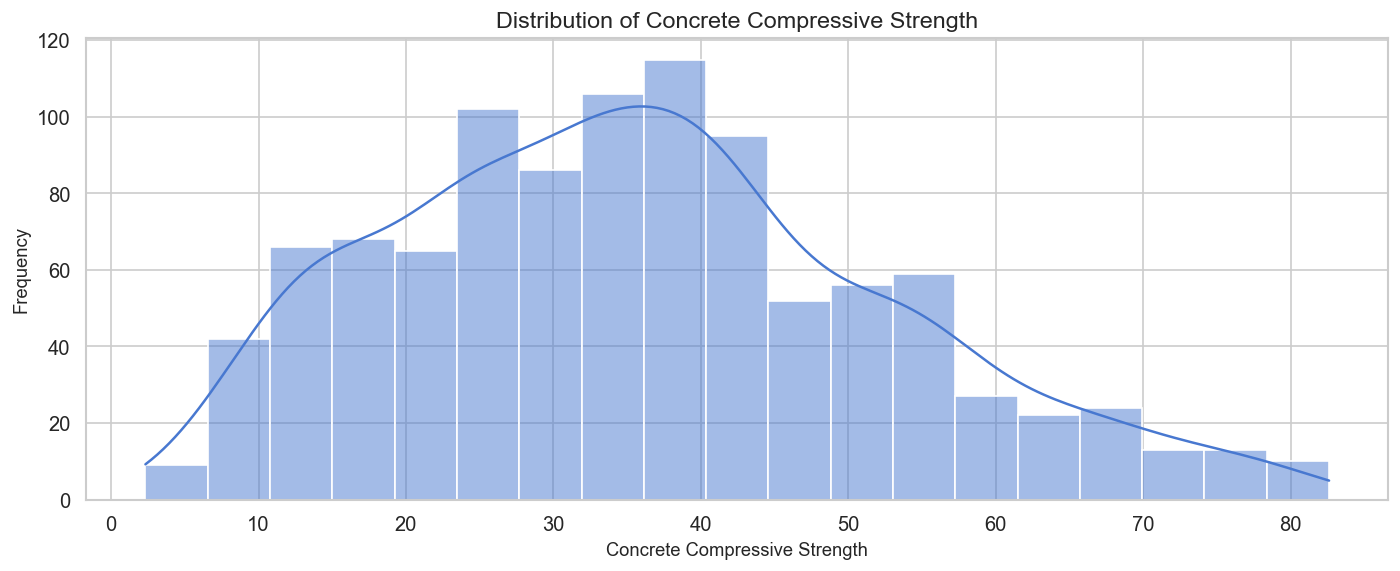

____________________________________________________________
Normal Distribution


In [5]:
sns.histplot(df['concrete_compressive_strength'],kde=True)
plt.title("Distribution of Concrete Compressive Strength")
plt.xlabel("Concrete Compressive Strength")
plt.ylabel("Frequency")

print(f"Skewness: {df['concrete_compressive_strength'].skew()}")
print("="*60)
plt.show()
print("_"*60)
print("Normal Distribution")



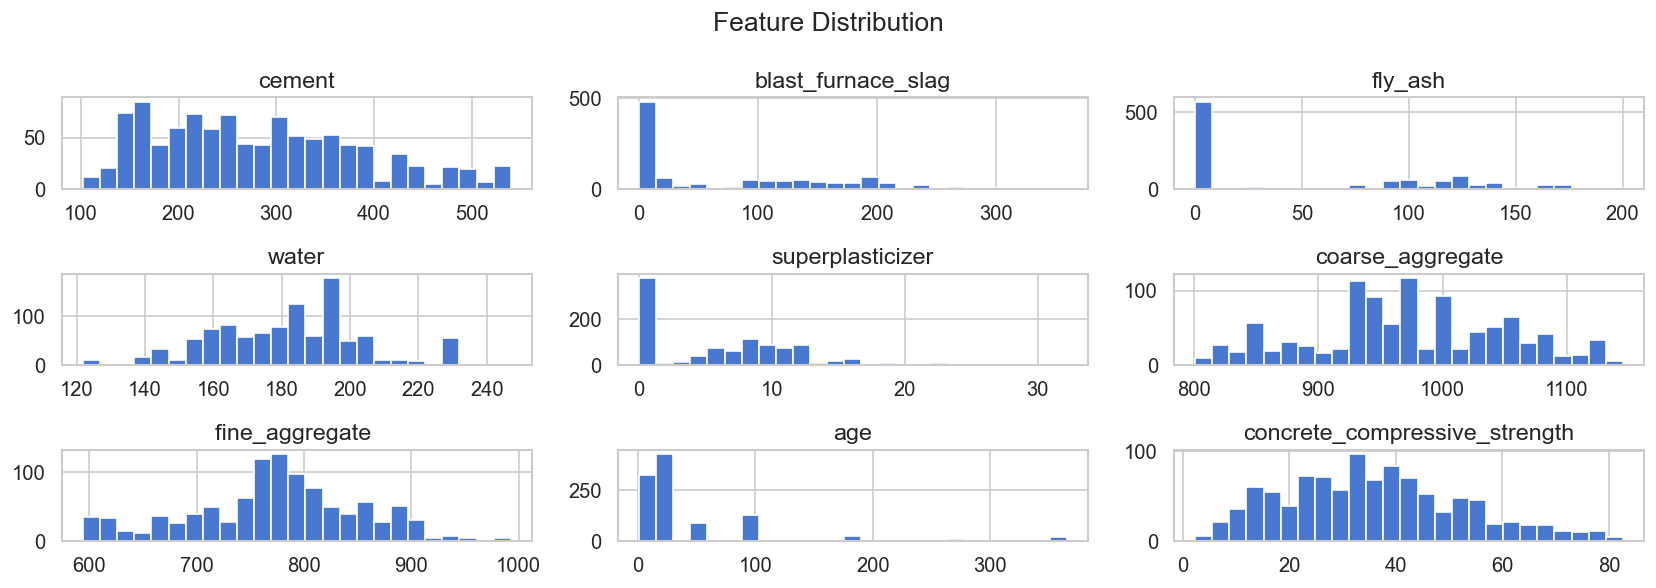

In [6]:
df.hist(bins=25)
plt.suptitle("Feature Distribution")
plt.tight_layout()
plt.show()

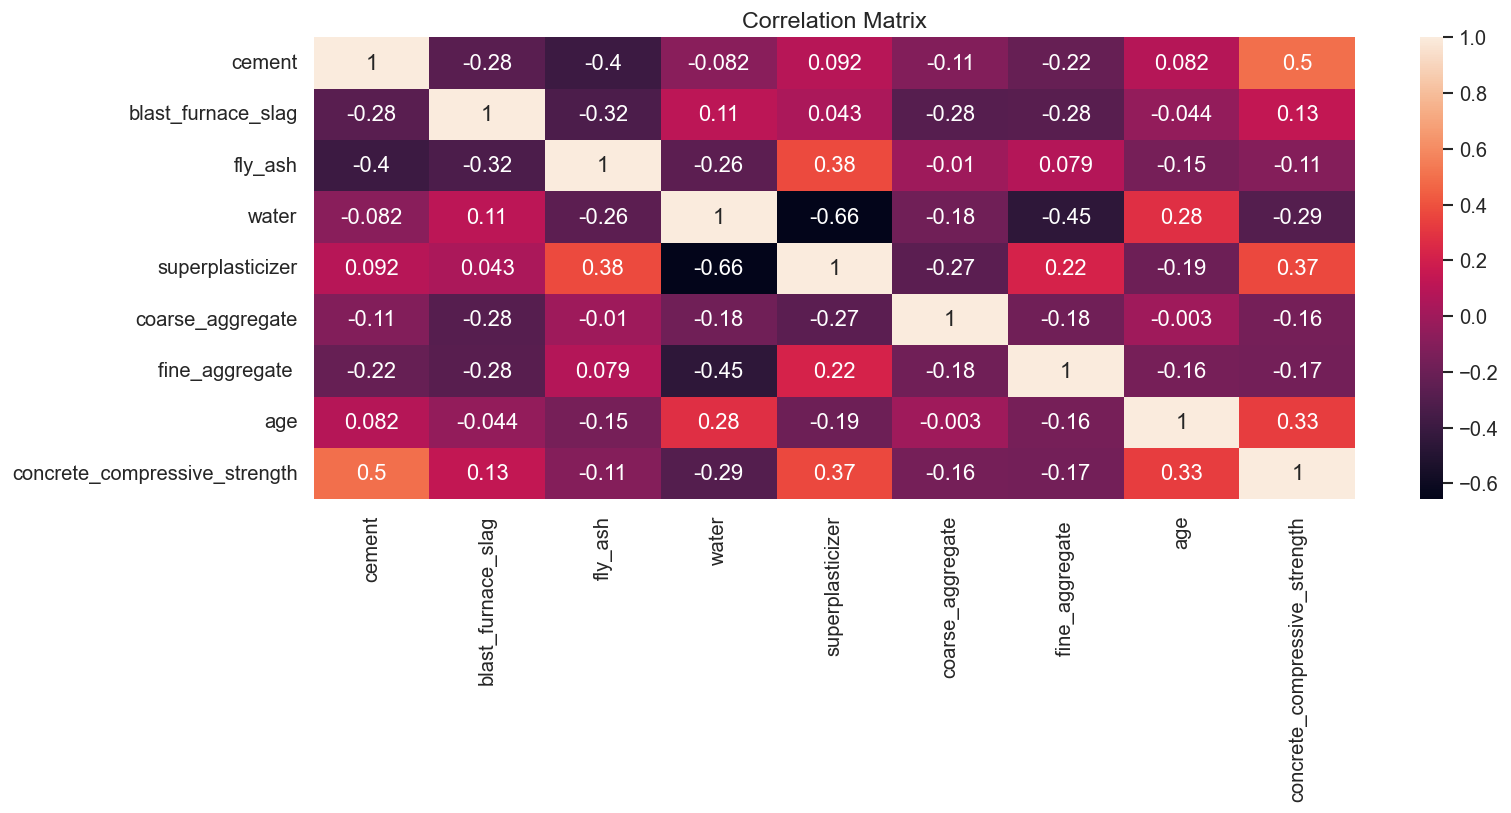

In [7]:

corr = df.corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()


---

># **Feature Engineering**  

In [8]:
df['wc_ratio'] = df['water'] / df['cement']


In [9]:
df['binder'] = df['cement'] + df['blast_furnace_slag'] + df['fly_ash']

In [10]:
df['log_age'] = np.log1p(df['age'])

In [11]:
df['has_slag']   = (df['blast_furnace_slag']   > 0).astype(int)
df['has_flyash'] = (df['fly_ash'] > 0).astype(int)
df['has_super']  = (df['superplasticizer'] > 0).astype(int)

print(df[['has_slag', 'has_flyash', 'has_super']].mean().round(2))

has_slag      0.54
has_flyash    0.45
has_super     0.63
dtype: float64


># **Data Preprocessing**  

In [12]:
print(f'Duplicates: {df.duplicated().sum()}')
print(f'Missing: {df.isnull().sum().sum()}')
print(f'Shape: {df.shape}')
df.describe().round(2)

Duplicates: 25
Missing: 0
Shape: (1030, 15)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength,wc_ratio,binder,log_age,has_slag,has_flyash,has_super
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82,0.75,409.25,3.24,0.54,0.45,0.63
std,104.51,86.28,64.00,21.35,5.97,77.75,80.18,63.17,16.71,0.31,92.78,1.11,0.50,0.50,0.48
min,102.00,0.00,0.00,121.80,0.00,801.00,594.00,1.00,2.33,0.27,200.00,0.69,0.00,0.00,0.00
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71,0.53,336.42,2.08,0.00,0.00,0.00
50%,272.90,22.00,0.00,185.00,6.40,968.00,779.50,28.00,34.44,0.68,391.30,3.37,1.00,0.00,1.00
75%,350.00,142.95,118.30,192.00,10.20,1029.40,824.00,56.00,46.14,0.94,483.70,4.04,1.00,1.00,1.00
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60,1.88,640.00,5.90,1.00,1.00,1.00


In [13]:
X = df.drop(columns=['concrete_compressive_strength'])
y = df['concrete_compressive_strength']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42     
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)        

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("scaled to train the machine learning base models")

scaled to train the machine learning base models


In [15]:
def add_all_features(df):
    df = df.copy()

    df['wc_ratio']         = df['water'] / df['cement']
    df['binder']           = df['cement'] + df['blast_furnace_slag'] + df['fly_ash']
    df['log_age']   = np.log1p(df['age'])
    df['has_slag']   = (df['blast_furnace_slag']   > 0).astype(int)
    df['has_flyash'] = (df['fly_ash'] > 0).astype(int)
    df['has_super']  = (df['superplasticizer'] > 0).astype(int)

    return df

X_train_fe = add_all_features(X_train)
X_test_fe  = add_all_features(X_test)


In [16]:
X_train_fe

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,wc_ratio,binder,log_age,has_slag,has_flyash,has_super
995,158.6,148.9,116.0,175.1,15.0,953.3,719.7,28,1.104035,423.5,3.367296,1,1,1
507,424.0,22.0,132.0,178.0,8.5,822.0,750.0,28,0.419811,578.0,3.367296,1,1,1
334,275.1,0.0,121.4,159.5,9.9,1053.6,777.5,3,0.579789,396.5,1.386294,0,1,1
848,252.0,97.0,76.0,194.0,8.0,835.0,821.0,28,0.769841,425.0,3.367296,1,1,1
294,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,3,0.937241,335.4,1.386294,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,3,0.505414,487.2,1.386294,1,0,1
330,246.8,0.0,125.1,143.3,12.0,1086.8,800.9,14,0.580632,371.9,2.708050,0,1,1
466,190.3,0.0,125.2,166.6,9.9,1079.0,798.9,100,0.875460,315.5,4.615121,0,1,1
121,475.0,118.8,0.0,181.1,8.9,852.1,781.5,28,0.381263,593.8,3.367296,1,0,1


---

># **Baseline Model**  

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"  RMSE : {rmse:.3f} MPa")
    print(f"  MAE  : {mae:.3f} MPa")
    print(f"  R²   : {r2:.4f}")
    return {'model': name, 'RMSE': round(rmse,3),
            'MAE': round(mae,3), 'R2': round(r2,4)}

results = [] 


In [18]:

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

print('=== Linear Regression — original features ===')
results.append(evaluate('Linear Regression (raw)', y_test, y_pred_lr))


=== Linear Regression — original features ===
  RMSE : 6.566 MPa
  MAE  : 5.332 MPa
  R²   : 0.8327


In [19]:
pipe_lr_fe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

pipe_lr_fe.fit(X_train_fe, y_train)
y_pred_lr_fe = pipe_lr_fe.predict(X_test_fe)

print('=== Linear Regression — engineered features ===')
results.append(evaluate('Linear Regression (FE)', y_test, y_pred_lr_fe))


=== Linear Regression — engineered features ===
  RMSE : 6.566 MPa
  MAE  : 5.332 MPa
  R²   : 0.8327


In [20]:
from sklearn.linear_model import Ridge, Lasso

for name, model in [('Ridge', Ridge(alpha=1.0)),
                      ('Lasso', Lasso(alpha=0.1))]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])
    pipe.fit(X_train_fe, y_train)
    y_pred = pipe.predict(X_test_fe)
    print(f"=== {name} ===")
    results.append(evaluate(name, y_test, y_pred))

=== Ridge ===
  RMSE : 6.563 MPa
  MAE  : 5.330 MPa
  R²   : 0.8328
=== Lasso ===
  RMSE : 6.552 MPa
  MAE  : 5.341 MPa
  R²   : 0.8334


In [21]:
from sklearn.linear_model import Ridge, Lasso

for name, model in [('Ridge', Ridge(alpha=1.0)),
                      ('Lasso', Lasso(alpha=0.1))]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  model)
    ])
    pipe.fit(X_train_fe, y_train)
    y_pred = pipe.predict(X_test_fe)
    print(f"=== {name} ===")
    results.append(evaluate(name, y_test, y_pred))

=== Ridge ===
  RMSE : 6.563 MPa
  MAE  : 5.330 MPa
  R²   : 0.8328
=== Lasso ===
  RMSE : 6.552 MPa
  MAE  : 5.341 MPa
  R²   : 0.8334


In [22]:
from sklearn.model_selection import cross_val_score

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))
])

cv_scores = cross_val_score(
    pipe_ridge, X_train_fe, y_train,
    cv=5, scoring='r2'
)

print(f"CV R² scores: {cv_scores.round(4)}")
print(f"Mean R²:      {cv_scores.mean():.4f}")
print(f"Std R²:       {cv_scores.std():.4f}")



CV R² scores: [0.8139 0.839  0.8611 0.8271 0.821 ]
Mean R²:      0.8324
Std R²:       0.0165


In [23]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(results_df.to_string(index=False))


                  model  RMSE   MAE     R2
                  Lasso 6.552 5.341 0.8334
                  Lasso 6.552 5.341 0.8334
                  Ridge 6.563 5.330 0.8328
                  Ridge 6.563 5.330 0.8328
 Linear Regression (FE) 6.566 5.332 0.8327
Linear Regression (raw) 6.566 5.332 0.8327


---

># **Model Comparison**  

In [24]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0))
    ]),
    'Decision Tree': Pipeline([
        ('model', DecisionTreeRegressor(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('model', RandomForestRegressor(
            n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('model', XGBRegressor(
            n_estimators=100, random_state=42,
            learning_rate=0.1, verbosity=0))
    ])
}

In [25]:
import numpy as np
from sklearn.model_selection import cross_val_score
import pandas as pd

cv_results = []

for name, pipe in models.items():
    scores = cross_val_score(
        pipe, X_train_fe, y_train,
        cv=5, scoring='r2', n_jobs=-1
    )
    rmse_scores = -cross_val_score(
        pipe, X_train_fe, y_train,
        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    cv_results.append({
        'Model':    name,
        'CV R²':    round(scores.mean(), 4),
        'R² Std':   round(scores.std(),  4),
        'CV RMSE':  round(rmse_scores.mean(), 3),
        'RMSE Std': round(rmse_scores.std(),  3),
    })
    print(f'{name:15s}  R²={scores.mean():.4f} ± {scores.std():.4f}  '
          f'RMSE={rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}')

cv_df = pd.DataFrame(cv_results).sort_values('CV R²', ascending=False)

Ridge            R²=0.8324 ± 0.0165  RMSE=6.870 ± 0.453
Decision Tree    R²=0.8252 ± 0.0349  RMSE=6.968 ± 0.566
Random Forest    R²=0.9082 ± 0.0153  RMSE=5.084 ± 0.552
XGBoost          R²=0.9151 ± 0.0185  RMSE=4.872 ± 0.570


In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

test_results = []

for name, pipe in models.items():
    pipe.fit(X_train_fe, y_train)
    y_pred = pipe.predict(X_test_fe)
    
    test_results.append({
        'Model': name,
        'Test R²':   round(r2_score(y_test, y_pred), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
        'Test MAE':  round(mean_absolute_error(y_test, y_pred), 3),
    })

test_df = pd.DataFrame(test_results).sort_values('Test R²', ascending=False)
print(test_df.to_string(index=False))

        Model  Test R²  Test RMSE  Test MAE
      XGBoost   0.9032      4.995     3.281
Random Forest   0.8935      5.238     3.424
        Ridge   0.8328      6.563     5.330
Decision Tree   0.7835      7.469     4.334


In [27]:
print('=== Overfitting Check (Train R² vs Test R²) ===')
print()

for name, pipe in models.items():
    pipe.fit(X_train_fe, y_train)
    r2_train = r2_score(y_train, pipe.predict(X_train_fe))
    r2_test  = r2_score(y_test,  pipe.predict(X_test_fe))
    gap      = r2_train - r2_test
    flag     = '  ← OVERFIT' if gap > 0.05 else ''
    print(f'{name:15s}  Train={r2_train:.4f}  Test={r2_test:.4f}  Gap={gap:.4f}{flag}')

=== Overfitting Check (Train R² vs Test R²) ===

Ridge            Train=0.8413  Test=0.8328  Gap=0.0085
Decision Tree    Train=0.9969  Test=0.7835  Gap=0.2135  ← OVERFIT
Random Forest    Train=0.9867  Test=0.8935  Gap=0.0931  ← OVERFIT
XGBoost          Train=0.9903  Test=0.9032  Gap=0.0872  ← OVERFIT


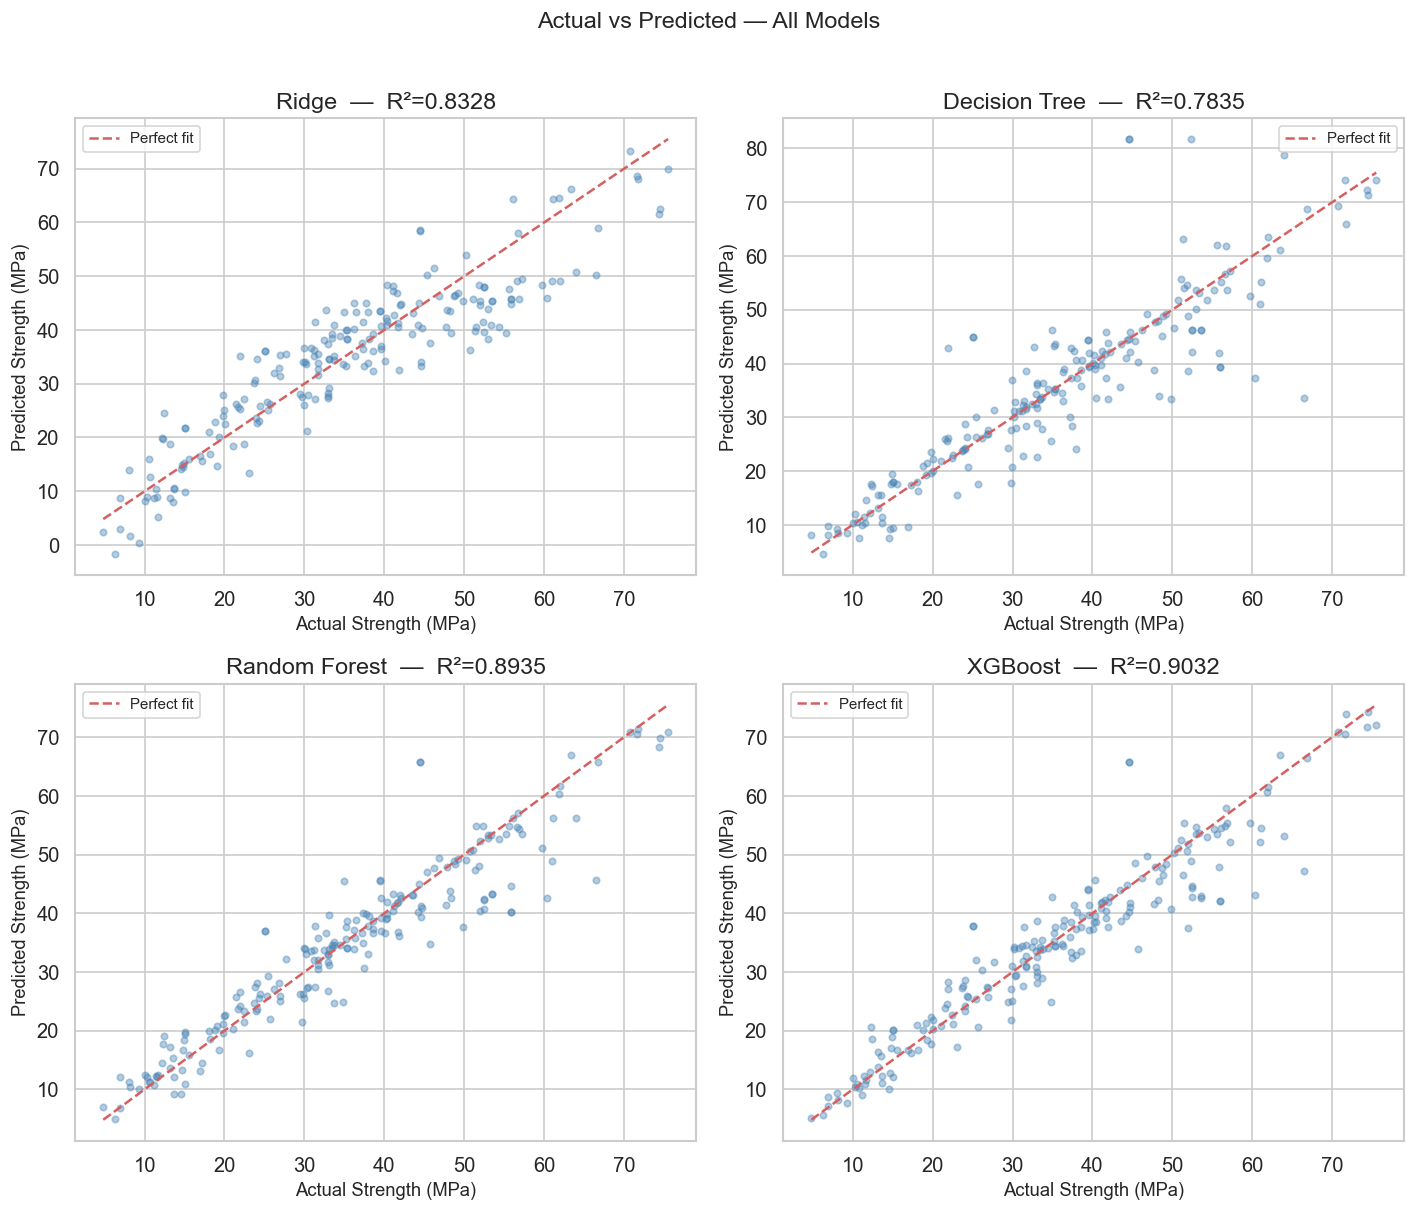

In [28]:


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, pipe) in zip(axes.flatten(), models.items()):
    y_pred = pipe.predict(X_test_fe)
    r2 = r2_score(y_test, y_pred)
    
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
    
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    
    ax.set_xlabel('Actual Strength (MPa)')
    ax.set_ylabel('Predicted Strength (MPa)')
    ax.set_title(f'{name}  —  R²={r2:.4f}')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---

># **Hyperparameter Tuning**  
   

In [29]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.8],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=50, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=1
)

rf_search.fit(X_train_fe, y_train)
print(f"Best CV R²: {rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")



Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV R²: 0.9149
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [30]:
from xgboost import XGBRegressor

xgb_param_grid = {
    'n_estimators':    [100, 200, 300, 500],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'max_depth':       [3, 4, 5, 6, 7],
    'subsample':       [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':[0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha':       [0, 0.01, 0.1, 1.0],
    'reg_lambda':      [0.5, 1.0, 2.0, 5.0],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    param_distributions=xgb_param_grid,
    n_iter=60,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train_fe, y_train)

print(f'Best R² (CV): {xgb_search.best_score_:.4f}')
print(f'Best params:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best R² (CV): 0.9302
Best params:
  subsample: 0.6
  reg_lambda: 1.0
  reg_alpha: 0.1
  n_estimators: 200
  max_depth: 7
  learning_rate: 0.05
  colsample_bytree: 0.6


In [31]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

best_rf  = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

for name, model in [('Random Forest (tuned)', best_rf),
                    ('XGBoost (tuned)',        best_xgb)]:
    y_pred = model.predict(X_test_fe)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    print(f'{name}')
    print(f'  R²   = {r2:.4f}')
    print(f'  RMSE = {rmse:.3f} MPa')
    print(f'  MAE  = {mae:.3f} MPa')


Random Forest (tuned)
  R²   = 0.9050
  RMSE = 4.948 MPa
  MAE  = 3.466 MPa
XGBoost (tuned)
  R²   = 0.9248
  RMSE = 4.403 MPa
  MAE  = 2.944 MPa


---

># **Interpretation & Feature Importance**  

In [32]:
importance_df = pd.DataFrame({
    'feature':    X_train_fe.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=True)

colors = ['#1D9E75' if f in ['wc_ratio','binder','log_age',
          'agg_binder_ratio','has_slag','has_flyash','has_super','is_mature']
          else '#378ADD'
          for f in importance_df['feature']]

ax.barh(importance_df['feature'], importance_df['importance'],
        color=colors, alpha=0.85)
ax.set_title('XGBoost Feature Importance')


Text(0.5, 1.0, 'XGBoost Feature Importance')

In [33]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_xgb, X_test_fe, y_test,
    n_repeats=10, random_state=42, scoring='r2'
)

perm_df = pd.DataFrame({
    'feature':          X_train_fe.columns,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std
}).sort_values('importance_mean', ascending=True)

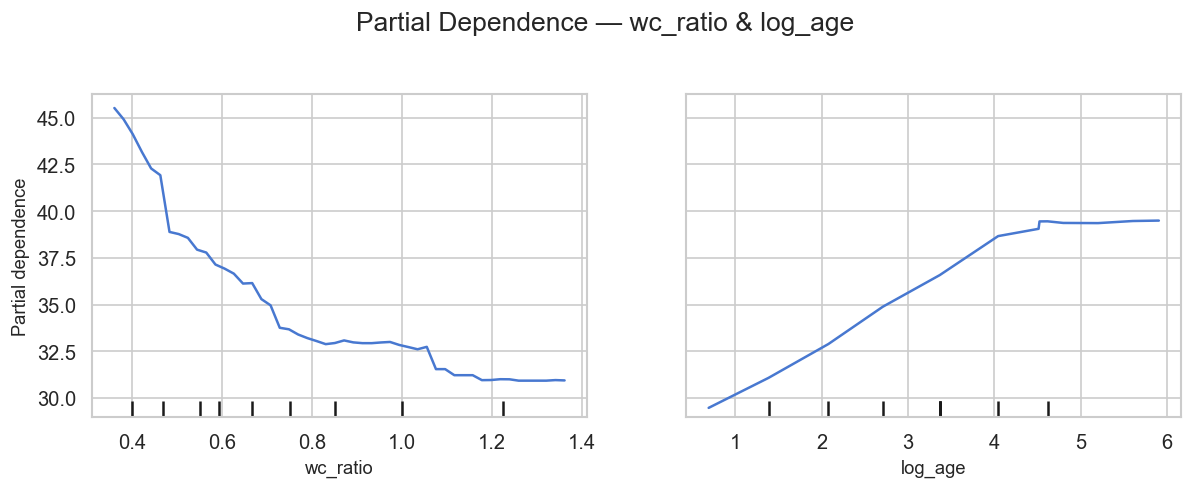

In [34]:

from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10, 4))

PartialDependenceDisplay.from_estimator(
    best_xgb,
    X_train_fe,
    features=['wc_ratio', 'log_age'],
    ax=ax,
    grid_resolution=50
)

plt.suptitle('Partial Dependence — wc_ratio & log_age', y=1.02)
plt.tight_layout()
plt.show()

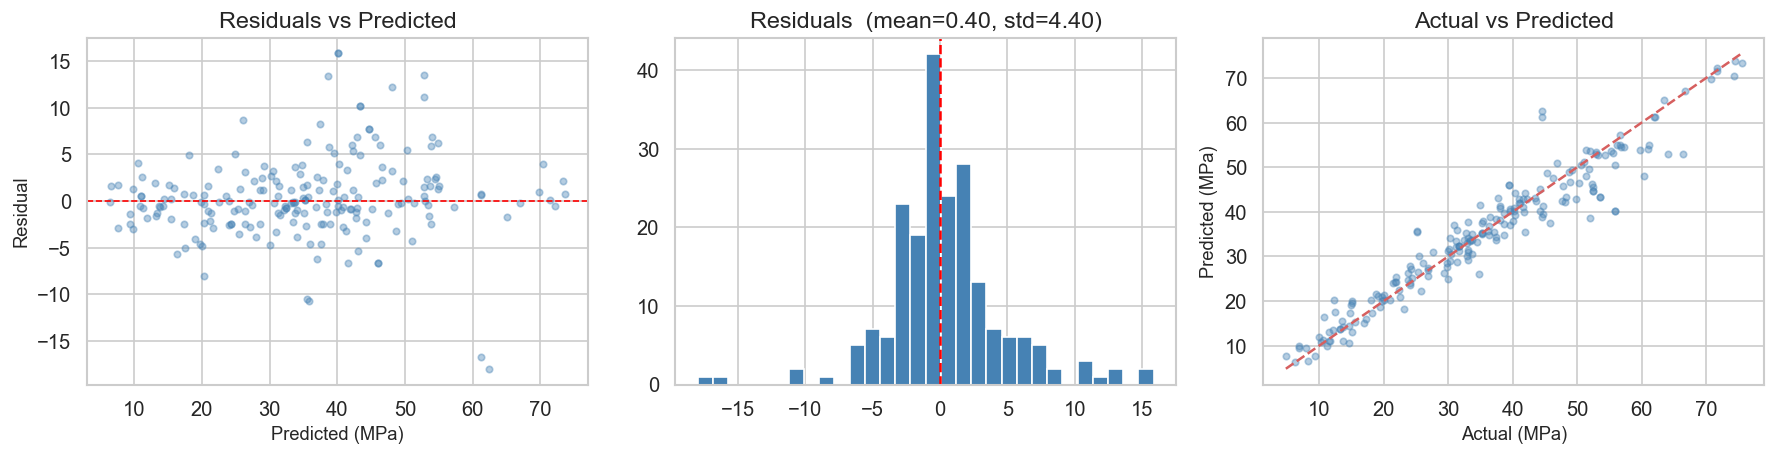

Max overestimate: -17.96 MPa
Max underestimate:15.83 MPa
Within ±5 MPa:    82.0% of samples


In [35]:
y_pred_final = best_xgb.predict(X_test_fe)
residuals    = y_test - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(15, 4))


axes[0].scatter(y_pred_final, residuals, alpha=0.4, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted (MPa)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title(f'Residuals  (mean={residuals.mean():.2f}, std={residuals.std():.2f})')


axes[2].scatter(y_test, y_pred_final, alpha=0.4, s=15, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[2].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
axes[2].set_xlabel('Actual (MPa)')
axes[2].set_ylabel('Predicted (MPa)')
axes[2].set_title('Actual vs Predicted')

plt.tight_layout()
plt.show()

print(f'Max overestimate: {residuals.min():.2f} MPa')
print(f'Max underestimate:{residuals.max():.2f} MPa')
print(f'Within ±5 MPa:    {(residuals.abs() <= 5).mean()*100:.1f}% of samples')